In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
import stir_simind_utils as utils
# plotting settings
plt.ion() # interactive 'on' such that plots appear during loops
#%% Import SIRF
import sirf.STIR as spect
import sirf.Utilities
import sirf.Reg as Reg
import numpy as np
import stir
from simind_python_connector import StirSimindAdaptor
import phantomgen as phantom
import numpy as np
import numexpr as ne
ne.set_num_threads(16) # use only 16 threads
import shutil
from pathlib import Path
demo_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1")

## Evaluate OSEM and OSEM-RM Reconstruction Performance

The quality of the reconstructed Tc-99m and Lu-177 images is evaluated using the **recovery coefficient (RC)** of the six NEMA spheres.

The known digital activity distribution provides a reference against which the reconstructed sphere activity can be compared.

In this step:

- OSEM reconstructions from **10 to 100 subiterations** are loaded.
- The NEMA **sphere masks** are used to define the regions for quantitative analysis.
- An **image calibration factor (ICF)** is calculated to account for differences in global image scaling.
- The **recovery coefficient** is calculated for each sphere at every reconstruction subiteration.
- RC is plotted as a function of subiteration to investigate **reconstruction convergence** and the effect of **sphere size on activity recovery**.
- The calibrated reconstruction at **100 subiterations** is displayed alongside the known activity distribution for visual comparison.

Ideally, a recovery coefficient of **1** indicates complete recovery of the known activity within the corresponding sphere. Smaller spheres are expected to show lower recovery due to the limited spatial resolution of the SPECT imaging system.

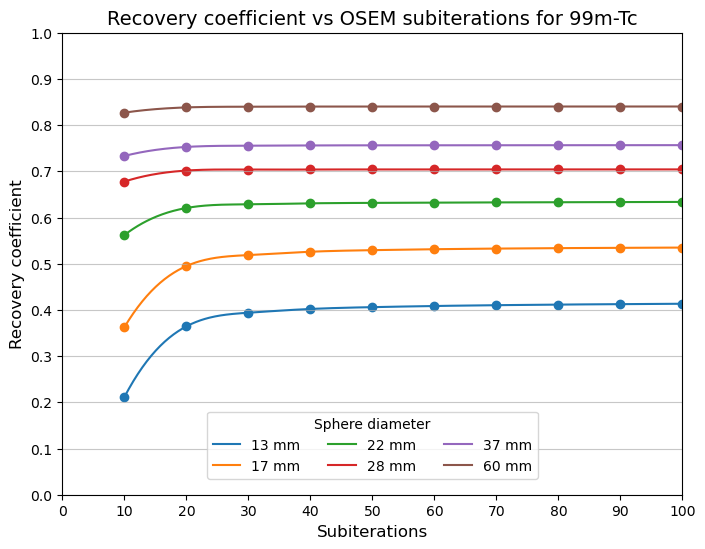

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': '99m-Tc Ground Truth'}>,
        <Axes: title={'center': 'Tc-99m OSEM reconstruction (sub=100)'}>],
       dtype=object))

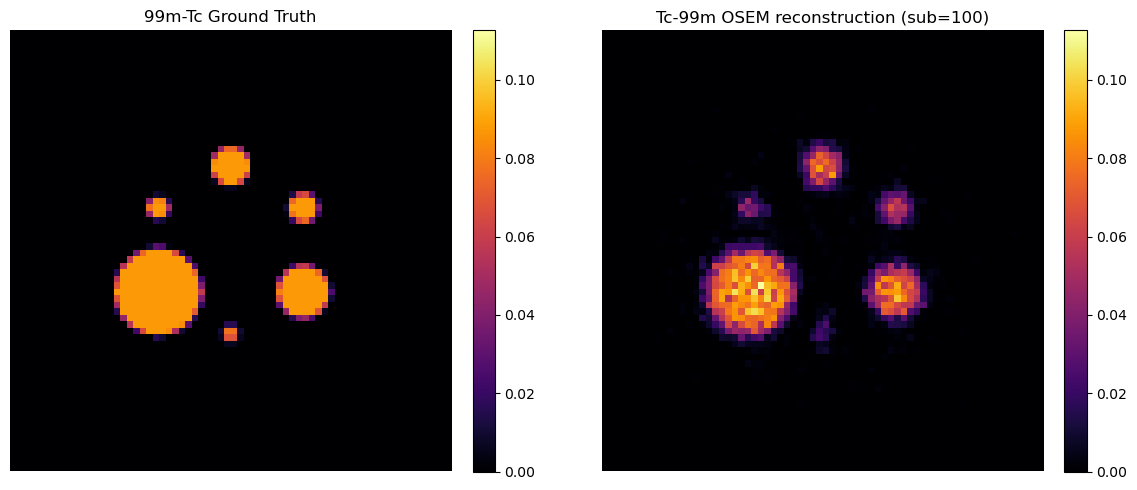

In [10]:
verbose = False

image_type = "tc99m_128"
source_name = "nema_tc_act.hv"
masks_name = "masks_tc.npz"

recon_type = "osem"
recon_prefix = "tc99m_sim_osem"

input_dir = demo_path / "simind_data" / image_type / "input"
recon_dir = demo_path / "simind_data" / image_type / "recons" / recon_type

# Load source image
nema_act_arr = spect.ImageData(
    str(input_dir / source_name)
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

osem_recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(input_dir / masks_name)
)

diametre_mm = [13, 17, 22, 28, 37, 60]

rc_data, icf = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=osem_recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    verbose=verbose
)

utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title="Recovery coefficient vs OSEM subiterations for 99m-Tc"
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = osem_recon_dict[str(subit)] / icf

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit],
    idx=idx,
    vmax=vmax,
    titles=["99m-Tc Ground Truth", f"Tc-99m OSEM reconstruction (sub={subit})"]
)

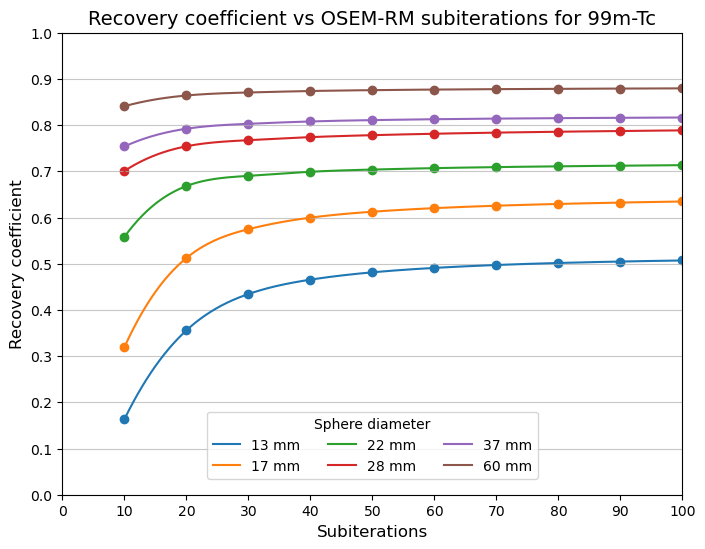

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': '99m-Tc Ground Truth'}>,
        <Axes: title={'center': '99m-Tc OSEM-RM reconstruction (sub=100)'}>],
       dtype=object))

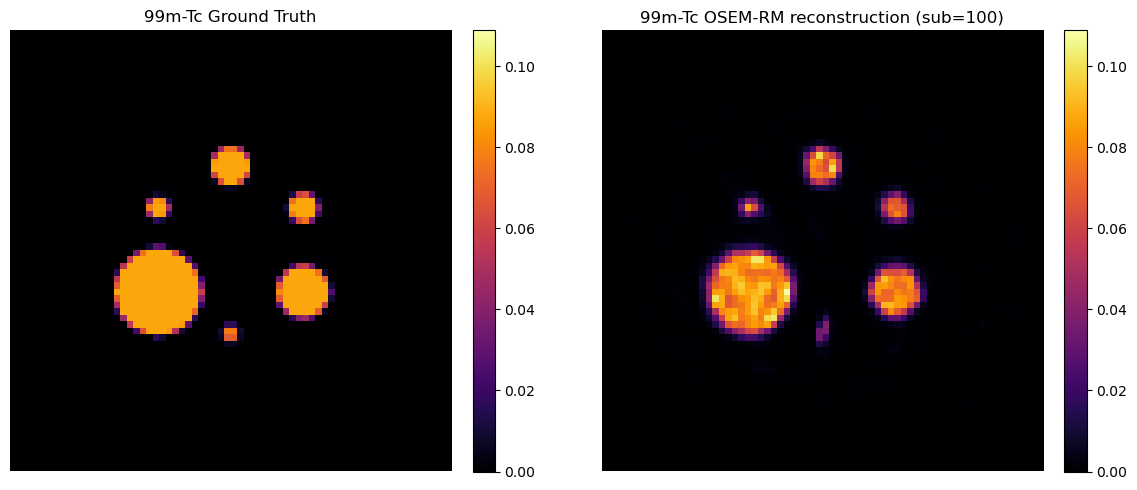

In [13]:
verbose = False

image_type = "tc99m_128"
source_name = "nema_tc_act.hv"
masks_name = "masks_tc.npz"

recon_type = "osem_rm"
recon_prefix = "tc99m_sim_osem_rm"

input_dir = demo_path / "simind_data" / image_type / "input"
recon_dir = demo_path / "simind_data" / image_type / "recons" / recon_type

# Load source image
nema_act_arr = spect.ImageData(
    str(input_dir / source_name)
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

osem_recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(input_dir / masks_name)
)

diametre_mm = [13, 17, 22, 28, 37, 60]

rc_data, icf = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=osem_recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    verbose=verbose
)

utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title="Recovery coefficient vs OSEM-RM subiterations for 99m-Tc"
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = osem_recon_dict[str(subit)] / icf

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit],
    idx=idx,
    vmax=vmax,
    titles=["99m-Tc Ground Truth", f"99m-Tc OSEM-RM reconstruction (sub={subit})"]
)

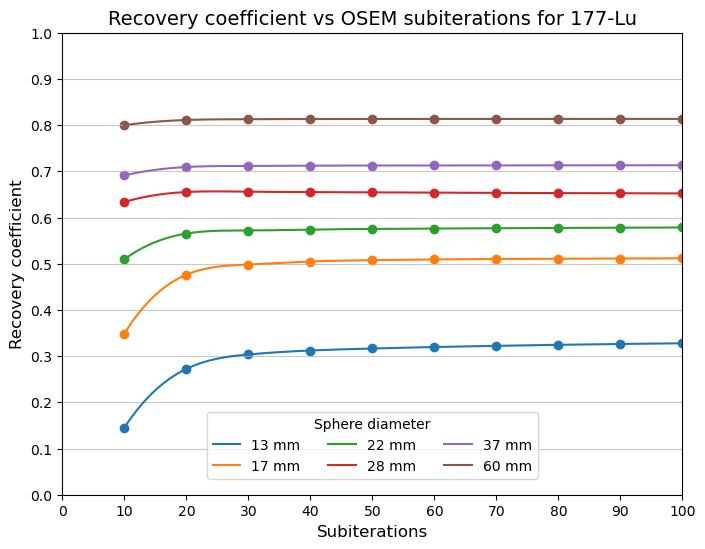

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': '177-Lu Ground Truth'}>,
        <Axes: title={'center': '177-Lu OSEM reconstruction (sub=100)'}>],
       dtype=object))

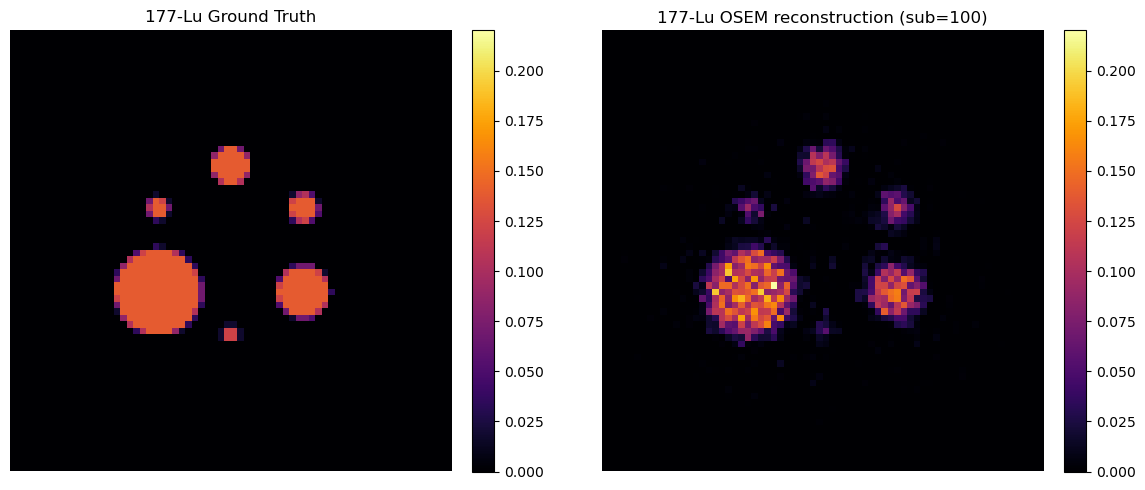

In [16]:
verbose = False

image_type = "lu177_128"
source_name = "nema_lu_act.hv"
masks_name = "masks_lu.npz"

recon_type = "osem"
recon_prefix = "lu177_sim_osem"

input_dir = demo_path / "simind_data" / image_type / "input"
recon_dir = demo_path / "simind_data" / image_type / "recons" / recon_type

# Load source image
nema_act_arr = spect.ImageData(
    str(input_dir / source_name)
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

osem_recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(input_dir / masks_name)
)

diametre_mm = [13, 17, 22, 28, 37, 60]

rc_data, icf = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=osem_recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    verbose=verbose
)

utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title="Recovery coefficient vs OSEM subiterations for 177-Lu"
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = osem_recon_dict[str(subit)] / icf

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit],
    idx=idx,
    vmax=vmax,
    titles=["177-Lu Ground Truth", f"177-Lu OSEM reconstruction (sub={subit})"]
)

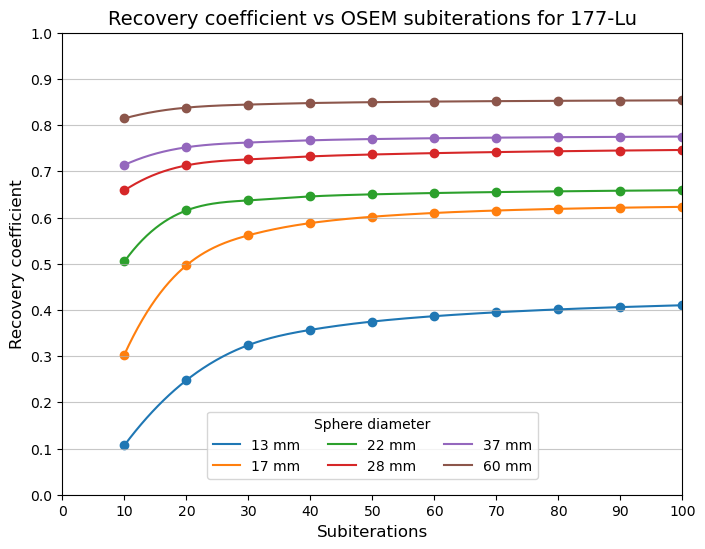

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': '177-Lu Ground Truth'}>,
        <Axes: title={'center': '177-Lu OSEM-RM reconstruction (sub=100)'}>],
       dtype=object))

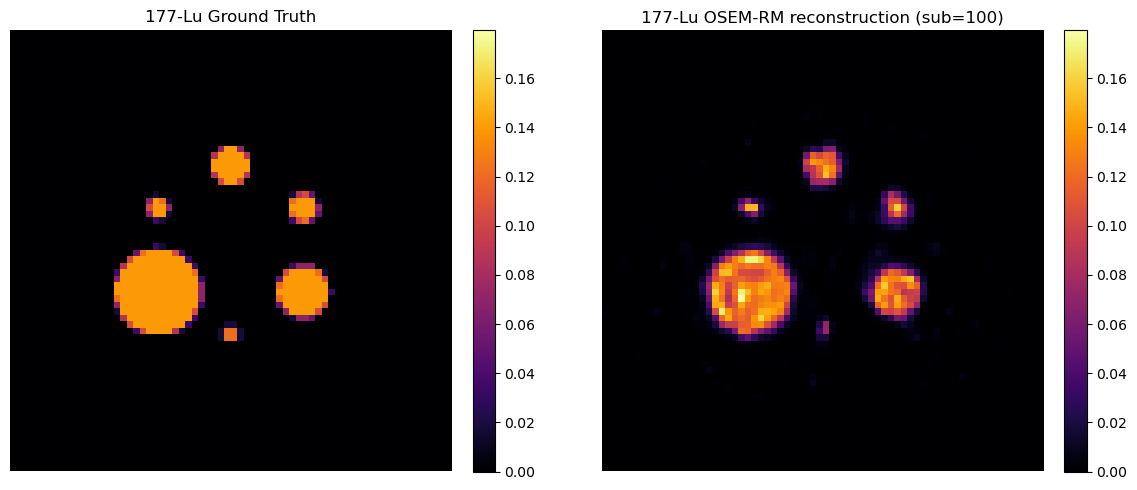

In [19]:
verbose = False

image_type = "lu177_128"
source_name = "nema_lu_act.hv"
masks_name = "masks_lu.npz"

recon_type = "osem_rm"
recon_prefix = "lu177_sim_osem"

input_dir = demo_path / "simind_data" / image_type / "input"
recon_dir = demo_path / "simind_data" / image_type / "recons" / recon_type

# Load source image
nema_act_arr = spect.ImageData(
    str(input_dir / source_name)
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

osem_recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(input_dir / masks_name)
)

diametre_mm = [13, 17, 22, 28, 37, 60]

rc_data, icf = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=osem_recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    verbose=verbose
)

utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title="Recovery coefficient vs OSEM subiterations for 177-Lu"
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = osem_recon_dict[str(subit)] / icf

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit],
    idx=idx,
    vmax=vmax,
    titles=["177-Lu Ground Truth", f"177-Lu OSEM-RM reconstruction (sub={subit})"]
)